## House-keeping

In [13]:
import os
import sys
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report

# Add project root to path
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)

# Import our custom evaluation and EDA tools
from src.evaluation.training_data_loader import load_pretrain_data
from src.evaluation.data_quality import warmup_clip
from src.evaluation.pretrain_report import _select_feature_cols
from src.evaluation.feature_signal import compute_ic, compute_mutual_information
from src.eda_utils import analyze_high_scores_shap, analyze_calibration

%load_ext autoreload
%autoreload 2

In [ ]:
# 1. Load the massive dense dataset (no targets included)
df_full = load_pretrain_data(mode='dense')
df = df_full[(df_full['date'] >= '2018-01-01') & (df_full['date'] <= '2024-12-31')].copy()
del df_full # Free up RAM

In [7]:
# 2. Sort chronologically by ticker to calculate future returns safely
df = df.sort_values(by=['ticker', 'date'])

# 3. Apply the warmup clip to ensure all rolling features are populated
df = warmup_clip(df)

# 4. Target Engineering: Calculate 20-day forward return
print("Calculating forward returns...")
df['future_close_20d'] = df.groupby('ticker')['close'].shift(-20)
df['return_20d'] = (df['future_close_20d'] - df['close']) / df['close']

# Drop rows at the end of the timeline that don't have 20 days of future data
df = df.dropna(subset=['return_20d'])

# 5. Create Binary Target (Home Run: 20-day return > 20%)
df['y_homerun'] = (df['return_20d'] > 0.20).astype(int)

# Check class imbalance on the slice
home_run_pct = df['y_homerun'].mean() * 100
print(f"Prototype Slice Trades: {len(df):,}")
print(f"Home Runs in slice: {df['y_homerun'].sum():,} ({home_run_pct:.1f}%)")
# Define features by automatically stripping metadata/leakage columns
feature_cols = _select_feature_cols(df)
print(f"Selected {len(feature_cols)} features for training.")


INFO:src.evaluation.data_quality:warmup_clip: 3674699 -> 3477067 rows (dropped 197632 leading-NULL)


Calculating forward returns...
Prototype Slice Trades: 3,426,158
Home Runs in slice: 208,613 (6.1%)
Selected 137 features for training.


## Preview Training Data

In [15]:
import importlib
import src.evaluation.feature_signal
# Force reload the module
importlib.reload(src.evaluation.feature_signal)
# Re-import the specific functions so they update in your namespace
from src.evaluation.feature_signal import compute_ic, compute_mutual_information

# Compute Information Coefficient (Spearman Rank) against the binary target
print("Computing Information Coefficient (IC) against y_homerun...")
ic_df = compute_ic(
    df, 
    feature_cols, 
    target='y_homerun',
    exclude=['return_20d', 'future_close_20d']  # Filter out our target engineering columns!
)

# Display the top 20 features driving Home Runs
display(ic_df.head(20))


Computing Information Coefficient (IC) against y_homerun...


,feature,spearman_ic,pval,abs_ic,low_signal
0,adr_20d,0.240408,0.0,0.240408,False
1,natr,0.237305,0.0,0.237305,False
2,consolidation_width,0.206064,0.0,0.206064,False
3,dist_from_52w_high,-0.176228,0.0,0.176228,False
4,pct_from_high_52w,-0.176228,0.0,0.176228,False
5,low_52w,-0.162702,0.0,0.162702,False
6,lowest_low_20d,-0.151292,0.0,0.151292,False
7,dist_from_20d_high,-0.147401,0.0,0.147401,False
8,ema_8,-0.143056,0.0,0.143056,False
9,sma_20,-0.141239,0.0,0.141239,False


In [16]:
# Optional: Run Mutual Information to capture non-linear relationships
mi_df = compute_mutual_information(
    df, 
    feature_cols, 
    target='y_homerun',
    exclude=['return_20d', 'future_close_20d']
)
display(mi_df.head(20))

,feature,mi_score
0,adr_20d,0.030188
1,natr,0.029609
2,m03_pillar_trend,0.023327
3,consolidation_width,0.021021
4,m03_regime_vol,0.020842
5,m03_pillar_risk,0.020214
6,rs,0.018526
7,dist_from_52w_high,0.018277
8,pct_from_high_52w,0.018242
9,ema_21_50_ratio,0.017435


## Model

### Train-Test Split & XGBoost Training

In [29]:
# Prepare X and y (ensuring targets are excluded)
exclude_cols = [
    'return_1d', 'return_5d', 'return_20d', 'return_60d', 
    'future_close_20d', 'y_homerun', 
    'mfe_pct', 'mae_pct', 'days_observed'
]
feature_cols = [f for f in feature_cols if f not in exclude_cols]

# Strict Chronological Split to prevent Overlapping Horizon Leakage
train_mask = df['date'] < '2023-01-01'
test_mask = df['date'] >= '2023-01-01'

X_train = df.loc[train_mask, feature_cols].copy()
y_train = df.loc[train_mask, 'y_homerun']

X_test = df.loc[test_mask, feature_cols].copy()
y_test = df.loc[test_mask, 'y_homerun']

# Convert categoricals
for col in X_train.select_dtypes(include=['object', 'category']).columns:
    X_train[col] = X_train[col].astype('category')
    X_test[col] = X_test[col].astype('category')

print(f"Training on {len(X_train)} samples (Pre-2023), testing on {len(X_test)} samples (2023+)")

# Calculate scale_pos_weight
scale_pos_weight = (len(y_train) - y_train.sum()) / (y_train.sum() + 1e-5)
print(f"Using scale_pos_weight: {scale_pos_weight:.2f}")

# Train the model
model = xgb.XGBClassifier(
    # ... keep your existing XGBoost params here ...
    objective='binary:logistic',
    n_estimators=100,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    enable_categorical=True,
    random_state=42,
    tree_method='hist'
)

model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=10
)


Training on 2359826 samples (Pre-2023), testing on 1066332 samples (2023+)
Using scale_pos_weight: 15.33
[0]	validation_0-logloss:0.67854	validation_1-logloss:0.67454
[10]	validation_0-logloss:0.58989	validation_1-logloss:0.55771
[20]	validation_0-logloss:0.55151	validation_1-logloss:0.50393
[30]	validation_0-logloss:0.53218	validation_1-logloss:0.47417
[40]	validation_0-logloss:0.52165	validation_1-logloss:0.45647
[50]	validation_0-logloss:0.51509	validation_1-logloss:0.44906
[60]	validation_0-logloss:0.50846	validation_1-logloss:0.43926
[70]	validation_0-logloss:0.50422	validation_1-logloss:0.43306
[80]	validation_0-logloss:0.50112	validation_1-logloss:0.42836
[90]	validation_0-logloss:0.49824	validation_1-logloss:0.42538
[99]	validation_0-logloss:0.49584	validation_1-logloss:0.42248


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


### Evaluation & Top-K Lift Analysis

In [33]:
# Generate prob_elite scores
y_pred_proba = model.predict_proba(X_test)[:, 1]

# 1. Base Metrics
roc_auc = roc_auc_score(y_test, y_pred_proba)
pr_auc = average_precision_score(y_test, y_pred_proba)
print(f"\nROC AUC: {roc_auc:.3f}")
print(f"PR AUC (Average Precision): {pr_auc:.3f}")

# 2. Top-K Lift (How dense are Home Runs in the top 100 scored trades?)
def calculate_top_k_lift(y_true, y_prob, ks=[10, 50, 100, 200]):
    base_rate = y_true.mean()
    print(f"\nBase Rate of Home Runs: {base_rate:.1%}")
    
    order = np.argsort(-y_prob)
    for k in ks:
        if k > len(y_true): continue
        top_k_idx = order[:k]
        hits = y_true.iloc[top_k_idx].sum()
        precision = hits / k
        lift = precision / base_rate
        print(f"Top {k}: {hits} hits | Precision: {precision:.1%} | Lift: {lift:.1f}x")

calculate_top_k_lift(y_test, y_pred_proba)

# 3. Score Calibration Analysis
# (Checks if a score of 0.60 actually means a 60% probability)
frac_pos, mean_pred, ece = analyze_calibration(y_test, y_pred_proba)
print(f"\nExpected Calibration Error (ECE): {ece:.3f}")



ROC AUC: 0.777
PR AUC (Average Precision): 0.180

Base Rate of Home Runs: 6.0%
Top 10: 9 hits | Precision: 90.0% | Lift: 15.0x
Top 50: 39 hits | Precision: 78.0% | Lift: 13.0x
Top 100: 60 hits | Precision: 60.0% | Lift: 10.0x
Top 200: 110 hits | Precision: 55.0% | Lift: 9.2x

Expected Calibration Error (ECE): 0.239


In [32]:
# Bind predictions back to date and ticker
results = X_test.copy()
results['date'] = df.loc[X_test.index, 'date']
results['ticker'] = df.loc[X_test.index, 'ticker']
results['y_true'] = y_test
results['y_prob'] = y_pred_proba

# Let's look at the Global Top 15 to prove your suspicion!
print("--- Global Top 15 Highest Scored Rows ---")
display(results.sort_values('y_prob', ascending=False)[['date', 'ticker', 'y_prob', 'y_true']].head(15))

# Now let's calculate REAL Daily Cross-Sectional Precision
def daily_top_k_precision(results_df, k=3):
    # Sort by date, then by probability descending
    sorted_df = results_df.sort_values(['date', 'y_prob'], ascending=[True, False])
    
    # Filter out days where the model has zero conviction (e.g. prob < 0.50)
    # to simulate days where we just sit in cash.
    tradable_days = sorted_df[sorted_df['y_prob'] > 0.50]
    
    # Take the top K tickers per day
    top_k_daily = tradable_days.groupby('date').head(k)
    
    precision = top_k_daily['y_true'].mean()
    total_trades = len(top_k_daily)
    
    print(f"\nDaily Cross-Sectional Top-{k} Precision: {precision:.1%} (over {total_trades} total daily picks)")
    return top_k_daily

top_3_daily = daily_top_k_precision(results, k=3)
top_5_daily = daily_top_k_precision(results, k=5)


--- Global Top 15 Highest Scored Rows ---


,date,ticker,y_prob,y_true
7454107,2023-01-05,OPEN,0.919707,1
7454105,2023-01-03,OPEN,0.918579,1
7525832,2023-05-05,BVS,0.918127,1
7435574,2023-03-16,CURV,0.917046,1
7877096,2023-10-20,FATE,0.916945,1
7454106,2023-01-04,OPEN,0.916109,1
7898211,2024-02-07,BW,0.915180,1
7373039,2023-03-16,GOSS,0.914531,0
7963972,2024-02-15,KULR,0.914154,1
7385983,2023-01-03,IMUX,0.913881,1



Daily Cross-Sectional Top-3 Precision: 35.4% (over 1446 total daily picks)

Daily Cross-Sectional Top-5 Precision: 36.2% (over 2410 total daily picks)


## SHAP vs. Gain Debate

In [31]:
# 1. XGBoost Native Gain
importance_dict = model.get_booster().get_score(importance_type='gain')
gain_df = pd.DataFrame([{'feature': k, 'gain': v} for k, v in importance_dict.items()])
gain_df = gain_df.sort_values('gain', ascending=False).head(15)

print("--- Top 15 Features by XGBoost GAIN ---")
display(gain_df)

# 2. SHAP Analysis on High-Confidence Predictions (prob_elite > 0.60)
print("\nRunning SHAP Analysis on high-scoring setups...")
shap_vals, shap_importance, X_high = analyze_high_scores_shap(
    model=model.get_booster(),
    X=X_test,
    y_prob=y_pred_proba,
    threshold=0.60,
    sample_size=500
)

print("--- Top 15 Features by SHAP (High Confidence Trades) ---")
display(shap_importance.head(15))


--- Top 15 Features by XGBoost GAIN ---


,feature,gain
61,adr_20d,60870.359375
29,natr,24077.750000
31,consolidation_width,18082.861328
16,dist_from_52w_high,11064.171875
17,dist_from_52w_low,8439.883789
19,pct_above_low_52w,7243.867188
11,rs,6161.039062
15,low_52w,6122.786621
82,m03_pillar_risk,5429.899902
18,pct_from_high_52w,4127.725098


INFO:src.eda_utils:Sampled 500 high-score trades for SHAP analysis



Running SHAP Analysis on high-scoring setups...
--- Top 15 Features by SHAP (High Confidence Trades) ---


,feature,mean_abs_shap
78,adr_20d,0.647366
127,m03_pillar_risk,0.281952
18,low_52w,0.183080
19,dist_from_52w_high,0.174515
33,natr,0.113483
20,dist_from_52w_low,0.071983
126,m03_pillar_liq,0.044482
35,vcp_ratio,0.041846
125,m03_pillar_trend,0.041645
21,pct_from_high_52w,0.037824


### Simplified Vectorized Backtest 

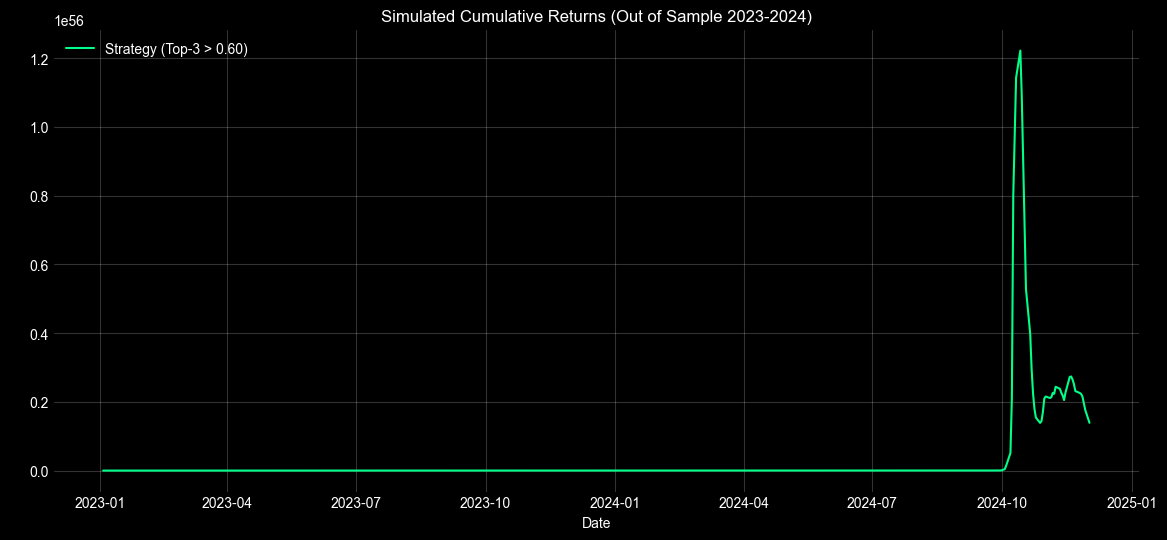

--- BACKTEST RESULTS ---
Total Trading Days: 482
Days with active setups: 482
Total Trades: 1446
Average Raw Return per Trade: 37.84%
Win Rate (>0%): 56.8%
Home Run Rate (>20%): 35.4%


In [36]:
# We need the actual 20-day returns to calculate portfolio equity
backtest_df = results.copy()
backtest_df['return_20d'] = df.loc[X_test.index, 'return_20d']

# 1. Apply our trading rules
# Buy if prob_elite > 0.60. (Optionally add: & (backtest_df['m03_score'] > 60))
actionable = backtest_df[backtest_df['y_prob'] >= 0.60].copy()

# 2. Daily Top-3 Selection
actionable = actionable.sort_values(['date', 'y_prob'], ascending=[True, False])
daily_picks = actionable.groupby('date').head(3)

# 3. Calculate Portfolio Performance
# Track the average 20-day return generated by the picks made on each calendar day
daily_returns = daily_picks.groupby('date')['return_20d'].mean()

# Fill days with no actionable picks with 0 return
all_dates = pd.Series(0.0, index=pd.to_datetime(results['date'].unique())).sort_index()
daily_returns.index = pd.to_datetime(daily_returns.index)
strategy_returns = daily_returns.reindex(all_dates.index, fill_value=0.0)

# Calculate cumulative return curve
# Note: Since this is 20-day returns stacked per day, it simulates a purely overlapping non-compounded strategy for visual shape.
cumulative_return = (1 + strategy_returns).cumprod() - 1

# Plot
plt.figure(figsize=(14, 6))
plt.plot(cumulative_return.index, cumulative_return.values * 100, label='Strategy (Top-3 > 0.60)', color='#00ff88')
plt.title('Simulated Cumulative Returns (Out of Sample 2023-2024)', color='white')
plt.ylabel('Cumulative Return (%)', color='black')
plt.xlabel('Date', color='white')
plt.grid(True, alpha=0.2)
plt.style.use('dark_background')
plt.legend()
plt.show()

# Stats
print("--- BACKTEST RESULTS ---")
print(f"Total Trading Days: {len(all_dates)}")
print(f"Days with active setups: {len(daily_returns)}")
print(f"Total Trades: {len(daily_picks)}")
print(f"Average Raw Return per Trade: {daily_picks['return_20d'].mean():.2%}")
print(f"Win Rate (>0%): {(daily_picks['return_20d'] > 0).mean():.1%}")
print(f"Home Run Rate (>20%): {(daily_picks['return_20d'] > 0.20).mean():.1%}")
